<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [7]:
# 'ResponseId' को छोड़कर बाकी सभी कॉलम्स के आधार पर डुप्लीकेट्स की गिनती
duplicate_count = df.duplicated(subset=df.columns.difference(['ResponseId'])).sum()
print(f"Total number of duplicate rows: {duplicate_count}")

# df.describe()

Total number of duplicate rows: 507


In [8]:
# डुप्लीकेट रोज़ को एक अलग DataFrame में देखना (ताकि आप पैटर्न समझ सकें)
duplicates_df = df[df.duplicated(subset=df.columns.difference(['ResponseId']), keep=False)]

# पहले 5-10 डुप्लीकेट रोज़ डिस्प्ले करना
print("First few duplicate rows:")
duplicates_df.sort_values(by='Country').head(10) # Country के हिसाब से सॉर्ट किया ताकि तुलना आसान हो


First few duplicate rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65456,36796,I am a developer by profession,65 years or older,Retired,NaN,Apples,NaN,Some college/university study without earning ...,"Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
36795,36796,I am a developer by profession,65 years or older,Retired,NaN,Apples,NaN,Some college/university study without earning ...,"Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65449,51198,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,3.0
51197,51198,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,3.0
35587,35588,"I am not primarily a developer, but I write co...",18-24 years old,"Student, full-time;Employed, part-time",In-person,Apples,Hobby;Contribute to open-source projects;Schoo...,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
40873,40874,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,Some college/university study without earning ...,Books / Physical media;Other online resources ...,Technical documentation;Blogs;Books;Stack Over...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,6.0
65455,40874,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,Some college/university study without earning ...,Books / Physical media;Other online resources ...,Technical documentation;Blogs;Books;Stack Over...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,6.0
65452,35588,"I am not primarily a developer, but I write co...",18-24 years old,"Student, full-time;Employed, part-time",In-person,Apples,Hobby;Contribute to open-source projects;Schoo...,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN


### Task 2: Analyze Characteristics of Duplicates
1. Identify duplicate rows based on selected columns such as MainBranch, Employment, and RemoteWork. Analyse which columns frequently contain identical values within these duplicate rows.
2. Analyse the characteristics of rows that are duplicates based on a subset of columns, such as MainBranch, Employment, and RemoteWork. Determine which columns frequently have identical values across these rows.
   


In [10]:
# 1. उन सभी रोज़ को फ़िल्टर करें जो इन 3 कॉलम्स में एक जैसी हैं
subset_cols = ['MainBranch', 'Employment', 'RemoteWork']
subset_duplicates = df[df.duplicated(subset=subset_cols, keep=False)]

print(f"Total rows with duplicate patterns in these columns: {len(subset_duplicates)}")


Total rows with duplicate patterns in these columns: 65290


In [11]:
# 1. उन सभी रोज़ को फ़िल्टर करें जो इन 3 कॉलम्स में एक जैसी हैं

duplicates_subset = df[df.duplicated(subset=['MainBranch', 'Employment', 'RemoteWork'], keep=False)]

# 2. इन डुप्लीकेट रोज़ में बाकी कॉलम्स (जैसे Country, Age) की सबसे कॉमन वैल्यूज़ (Mode) निकालें
common_values = duplicates_subset[['Country', 'Age', 'EdLevel', 'YearsCode']].mode().iloc[0]

# 3. रिजल्ट दिखाएँ (जैसे Top 10 कॉलम्स जहाँ वैल्यूज़ सबसे ज़्यादा Identical हैं)
print("Characteristics of Duplicate Rows (Most Frequent Values):")
print(common_characteristics[['Country', 'Age', 'EdLevel', 'YearsCode']].to_frame(name='Most Identical Value'))



Characteristics of Duplicate Rows (Most Frequent Values):
                                   Most Identical Value
Country                        United States of America
Age                                     25-34 years old
EdLevel    Bachelor’s degree (B.A., B.S., B.Eng., etc.)
YearsCode                                            10


In [17]:
common_values_count = duplicates_subset[['Country', 'Age', 'EdLevel', 'YearsCode']].value_counts().head(5)
common_values_count


Country                   Age              EdLevel                                       YearsCode
United States of America  25-34 years old  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  10           279
India                     18-24 years old  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  4            221
United States of America  25-34 years old  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  12           197
India                     18-24 years old  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  3            196
United States of America  25-34 years old  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  15           191
Name: count, dtype: int64

### Task 3: Visualize Duplicates Distribution
1. Create visualizations to show the distribution of duplicates across different categories.
2. Use bar charts or pie charts to represent the distribution of duplicates by Country and Employment.


Text(0, 0.5, 'Number of Duplicate Rows')

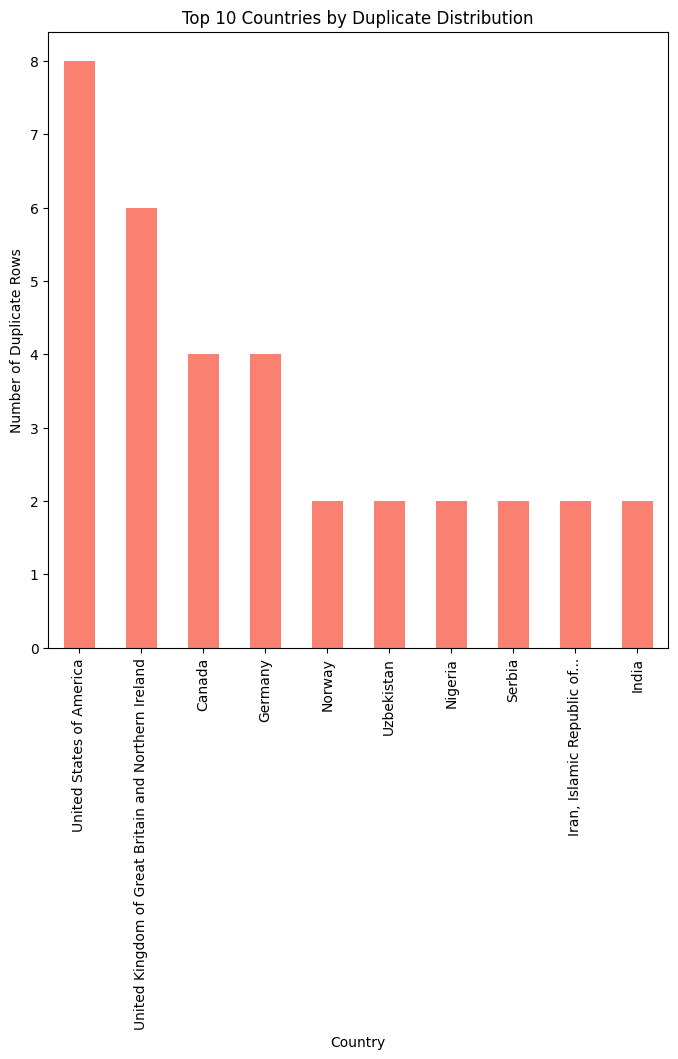

In [18]:
# 2. Bar Chart: Top 10 Countries with most duplicates
plt.figure(figsize=(8, 8))

duplicates_df['Country'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Countries by Duplicate Distribution')
plt.ylabel('Number of Duplicate Rows')



Text(0, 0.5, '')

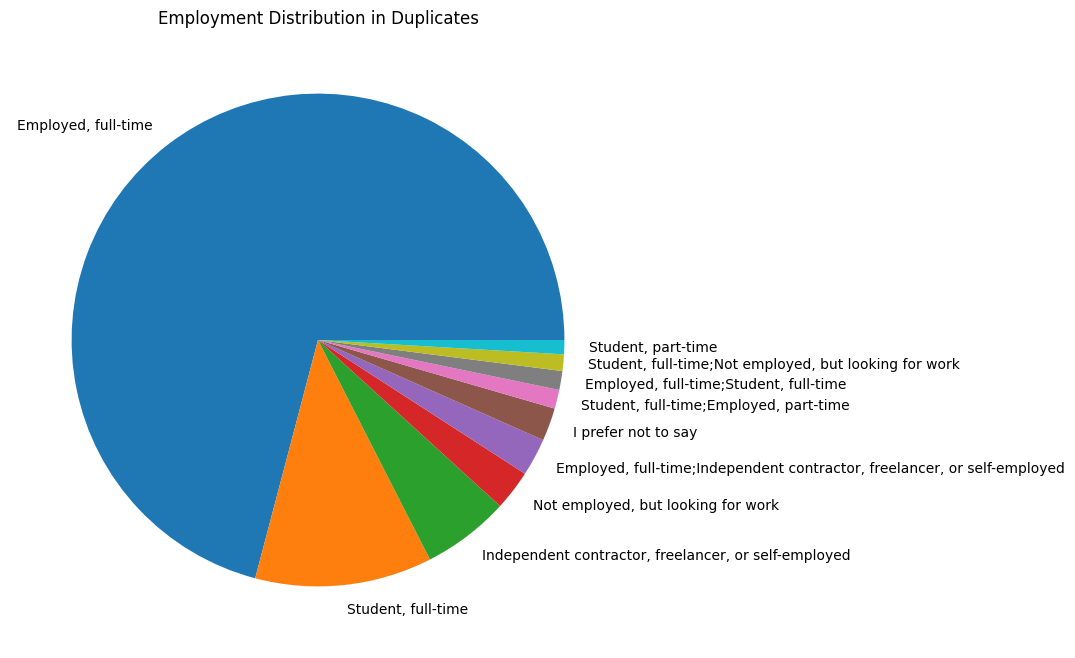

In [19]:
plt.figure(figsize=(8, 8))

duplicates_df['Employment'].value_counts().head(10).plot(kind='pie', color='salmon')
plt.title('Employment Distribution in Duplicates')
plt.ylabel('') # y-label हटाने के लिए


Text(0, 0.5, 'Number of Duplicate Rows')

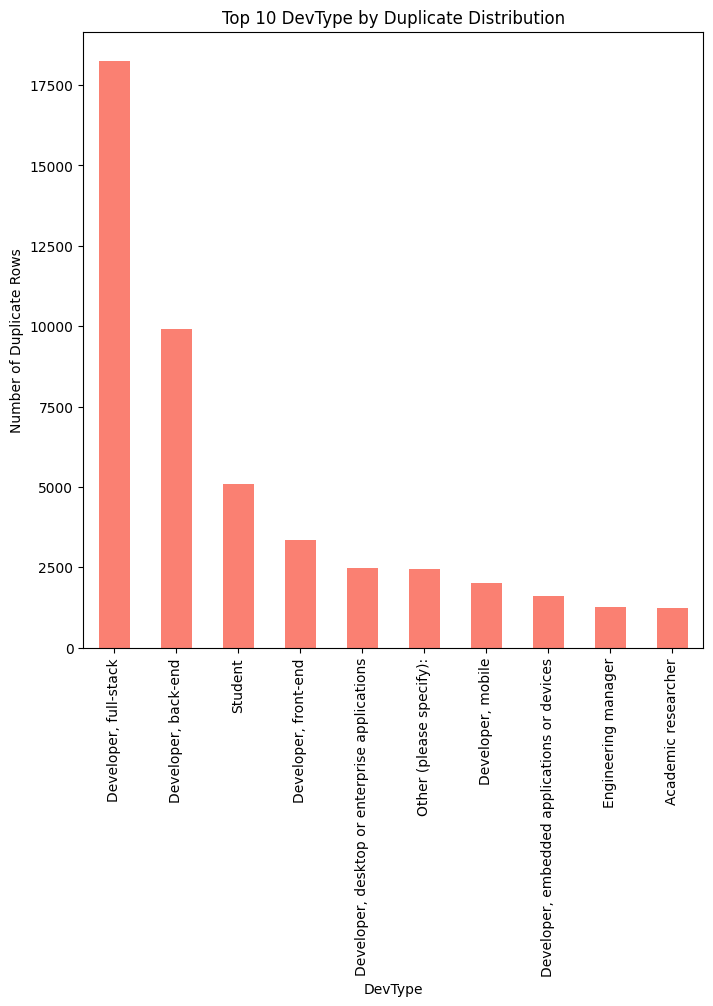

In [20]:
# 4. Bar Chart: Top 10 DevType with most duplicates
plt.figure(figsize=(8, 8))

duplicates_subset['DevType'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 DevType by Duplicate Distribution')
plt.ylabel('Number of Duplicate Rows')

### Task 4: Strategic Removal of Duplicates
1. Decide which columns are critical for defining uniqueness in the dataset.
2. Remove duplicates based on a subset of columns if complete row duplication is not a good criterion.


In [21]:
## Write your code here
critical_columns = ['Country', 'Age', 'MainBranch', 'Employment', 'RemoteWork']
new_duplicate_count = df.duplicated(subset=critical_columns).sum()
print(f"Duplicates based on critical profile: {new_duplicate_count}")


Duplicates based on critical profile: 53316


In [22]:
critical_cols = ['Country', 'Age', 'MainBranch', 'Employment', 'RemoteWork']
df_cleaned = df.drop_duplicates(subset=critical_cols, keep='first')
print(f"सफाई से पहले Rows: {len(df)}")
print(f"सफाई के बाद Rows: {len(df_cleaned)}")

सफाई से पहले Rows: 65457
सफाई के बाद Rows: 12141


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
